In [29]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [30]:
!pip install mlxtend --quiet

In [31]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [32]:
#Importar tabla productos
productos = pd.read_csv('/content/productos_clean.csv')
productos.head()

,Fecha,Nro. del Pedido,Nombre del Producto,Variación del Producto,Cantidad,Precio,Descuento,Hora,DiaSemana,FechaNegocio,DiaNegocio,Mesero
0,2022-06-10 19:22:00,1110,Shirley Temple,Sin variación,2.0,10.0,0.0,19:22:00,Viernes,2022-06-10,Viernes,Sin registrar
1,2022-06-10 19:23:00,1111,Freddie Mercury,Sin variación,1.0,25.0,0.0,19:23:00,Viernes,2022-06-10,Viernes,Sin registrar
2,2022-06-10 19:23:00,1111,Michael Jackson,Sin variación,1.0,20.0,0.0,19:23:00,Viernes,2022-06-10,Viernes,Sin registrar
3,2022-06-10 19:26:00,1112,Jarra Appleton,Sin variación,1.0,38.0,0.0,19:26:00,Viernes,2022-06-10,Viernes,Sin registrar
4,2022-06-10 19:26:00,1112,Pilsen,Sin variación,1.0,10.0,0.0,19:26:00,Viernes,2022-06-10,Viernes,Sin registrar


In [33]:
transacciones = productos.groupby("Nro. del Pedido")["Nombre del Producto"].apply(list).tolist()

print(transacciones[:3])
print(f"Total de pedidos (transacciones): {len(transacciones)}")

[['Shirley Temple'], ['Freddie Mercury', 'Michael Jackson'], ['Jarra Appleton', 'Pilsen', 'Cuzqueña Malta', 'Coca Cola 500 ml']]
Total de pedidos (transacciones): 45068


In [34]:
te = TransactionEncoder()
te_array = te.fit(transacciones).transform(transacciones)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(df_encoded.shape)  # (n_pedidos, n_productos_únicos)
df_encoded.head()

(45068, 180)


,Absolut,Agua Cielo 2.25 L,Agua Cielo 500 ml,Agua San Luis 2.25 L,Agua San Luis 2.5 L,Agua San Luis 500 ml,Agua San Luis 500 ml sin gas,Agua San Mateo 500 ml,Alitas BBQ,Alitas Picantes,...,Vino Queirolo,Vodka Russkaya,Vodka Skyy,Vodka Smirnoff,Whisky Ballatines,Whisky Grants,Whisky Jack Daniels,Whisky Jack Daniels Honey,Whisky Johnnie Walker Negro,Whisky Johnnie Walker Rojo
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [35]:
from mlxtend.frequent_patterns import apriori, association_rules

# min_support: qué % mínimo de pedidos debe tener ese conjunto de productos para considerarse "frecuente"
# Con 45,068 pedidos, un min_support de 0.01 significa "al menos ~450 pedidos"
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")
frequent_itemsets.sort_values("support", ascending=False).head(10)

Conjuntos frecuentes encontrados: 31


,support,itemsets
28,0.125699,(Pilsen)
10,0.096388,(Cuzqueña Trigo)
1,0.060975,(Agua San Luis 500 ml sin gas)
9,0.050213,(Cuzqueña Malta)
21,0.035768,(Jarra Pomalca Rubio)
6,0.028845,(Coca Cola 500 ml)
14,0.028668,(Jarra Cartavio Black)
5,0.027314,(Chicharron de pollo)
0,0.027048,(Agua Cielo 500 ml)
23,0.026249,(Limon)


In [36]:
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(lambda x: len(x))

# Filtra solo combinaciones de 2 o más productos
combos = frequent_itemsets[frequent_itemsets["length"] >= 2].sort_values("support", ascending=False)
print(f"Combinaciones de 2+ productos: {len(combos)}")
combos.head(15)

Combinaciones de 2+ productos: 0


,support,itemsets,length


In [37]:
frequent_itemsets = apriori(df_encoded, min_support=0.003, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(lambda x: len(x))
combos = frequent_itemsets[frequent_itemsets["length"] >= 2].sort_values("support", ascending=False)
print(f"Combinaciones de 2+ productos: {len(combos)}")
combos.head(15)

Combinaciones de 2+ productos: 4


,support,itemsets,length
68,0.006701,"(Cuzqueña Malta, Cuzqueña Trigo)",2
70,0.006257,"(Cuzqueña Trigo, Pilsen)",2
69,0.003950,"(Cuzqueña Malta, Pilsen)",2
71,0.003395,"(Inca Kola 500 ml, Pilsen)",2


In [38]:
#Reglas de asociacion
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False)

print(f"Reglas generadas: {len(rules)}")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

Reglas generadas: 4


,antecedents,consequents,support,confidence,lift
3,(Pilsen),(Inca Kola 500 ml),0.003395,0.027008,2.139181
2,(Inca Kola 500 ml),(Pilsen),0.003395,0.268893,2.139181
1,(Cuzqueña Trigo),(Cuzqueña Malta),0.006701,0.069521,1.384525
0,(Cuzqueña Malta),(Cuzqueña Trigo),0.006701,0.133451,1.384525


In [39]:
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]])

          antecedents         consequents   support  confidence      lift
3            (Pilsen)  (Inca Kola 500 ml)  0.003395    0.027008  2.139181
2  (Inca Kola 500 ml)            (Pilsen)  0.003395    0.268893  2.139181
1    (Cuzqueña Trigo)    (Cuzqueña Malta)  0.006701    0.069521  1.384525
0    (Cuzqueña Malta)    (Cuzqueña Trigo)  0.006701    0.133451  1.384525


In [40]:
tamaño_pedido = productos.groupby("Nro. del Pedido")["Nombre del Producto"].count()
print(tamaño_pedido.describe())
print(f"% de pedidos con un solo producto: {(tamaño_pedido == 1).mean() * 100:.1f}%")

count    45068.000000
mean         1.152370
std          0.441101
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: Nombre del Producto, dtype: float64
% de pedidos con un solo producto: 87.0%


In [41]:
%%writefile README.md
## Market Basket Analysis

**Nota metodológica importante:** el sistema POS genera un "pedido" (ticket)
por cada ronda de consumo, no por mesa ni por visita completa. Una misma
mesa puede generar varios pedidos independientes a lo largo de una noche
(ej. una ronda de bebidas, y horas después otra). Esto significa que el
análisis identifica productos que se piden juntos *en un mismo momento*,
no el patrón de consumo completo de un cliente durante toda su visita.

Esto se confirma en los datos: el 87% de los pedidos (39,209 de 45,068)
contienen un solo producto, con un promedio de 1.15 productos por pedido.
Bajo esta estructura, es esperable encontrar pocas combinaciones
frecuentes de 2+ productos — no es una limitación del algoritmo, sino de
la unidad de análisis disponible.

Aun así, se encontraron dos asociaciones con soporte estadístico (Apriori,
min_support=0.003, lift ≥ 1.0):

- **Inca Kola → Pilsen** (confianza 26.9%, lift 2.14): los pedidos que
  incluyen Inca Kola tienen más del doble de probabilidad de incluir
  también una Pilsen, comparado con el promedio general — posible patrón
  de consumo mixto alcohol/no-alcohol dentro de un mismo grupo.
- **Cuzqueña Trigo ↔ Cuzqueña Malta** (lift 1.38): asociación moderada,
  consistente con clientes explorando variantes de una misma marca.

**Recomendación para el negocio:** un análisis de combos más preciso
orientado a "qué se consume por mesa en una visita completa" requeriría
que el sistema POS capture un identificador de mesa que agrupe los
pedidos de una misma sesión de consumo — una mejora concreta derivada de
este análisis.

Overwriting README.md


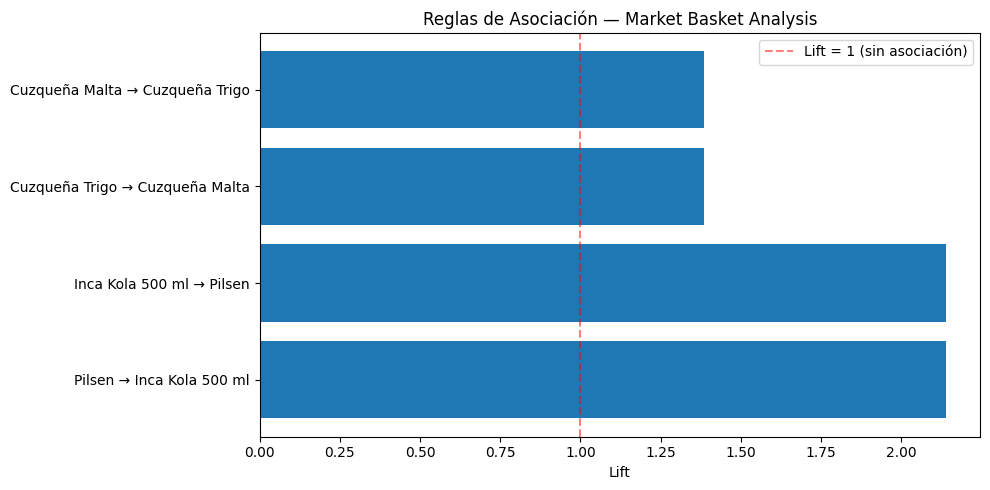

In [28]:
import matplotlib.pyplot as plt
import os

rules_plot = rules.copy()

# Extrae solo el nombre del producto de cada frozenset (une con coma si hay más de uno)
rules_plot["antecedents_str"] = rules_plot["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_plot["consequents_str"] = rules_plot["consequents"].apply(lambda x: ", ".join(list(x)))
rules_plot["regla"] = rules_plot["antecedents_str"] + " → " + rules_plot["consequents_str"]

plt.figure(figsize=(10, 5))
plt.barh(rules_plot["regla"], rules_plot["lift"], color="#1f77b4")
plt.xlabel("Lift")
plt.title("Reglas de Asociación — Market Basket Analysis")
plt.axvline(x=1, color="red", linestyle="--", alpha=0.5, label="Lift = 1 (sin asociación)")
plt.legend()
plt.tight_layout()

os.makedirs("img", exist_ok=True)
plt.savefig("img/market_basket_rules.png", dpi=150, bbox_inches="tight")
plt.show()